In [57]:
import nltk

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import matplotlib.patches as mpatches

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


False

In [58]:
qna_dev_00 = pd.read_csv("./data/00_QnA_dev.csv")
qna_eng_00 = pd.read_csv("./data/00_QnA_eng.csv")

qna_dev_01 = pd.read_csv("./data/01_QnA_dev.csv")
qna_eng_01 = pd.read_csv("./data/01_QnA_eng.csv")

qna_dev_02 = pd.read_csv("./data/02_QnA_dev.csv")
qna_eng_02 = pd.read_csv("./data/02_QnA_eng.csv")

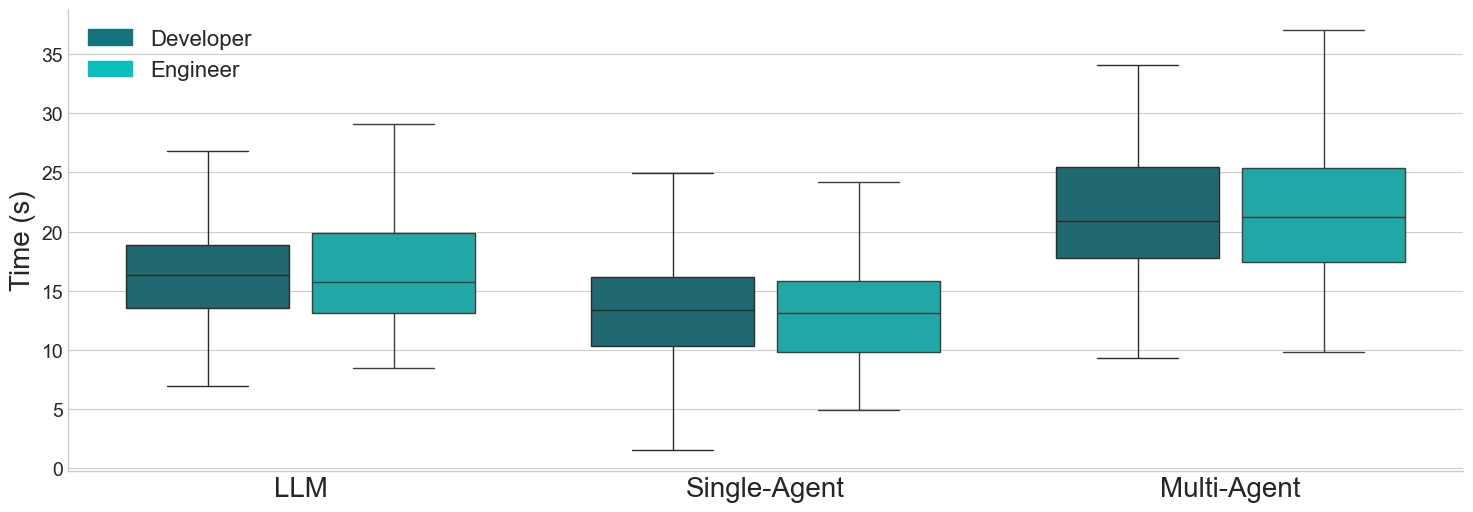

In [59]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(18, 6))

dev_data = pd.DataFrame({
    '00': qna_dev_00['duration'],
    '01': qna_dev_01['duration'],
    '02': qna_dev_02['duration'],
})

eng_data = pd.DataFrame({
    '00': qna_eng_00['duration'],
    '01': qna_eng_01['duration'],
    '02': qna_eng_02['duration'],
})

dev_melted = dev_data.melt(var_name='cenario', value_name='duration')
eng_melted = eng_data.melt(var_name='cenario', value_name='duration')

dev_melted['arquitetura'] = 'Developer'
eng_melted['arquitetura'] = 'Engineer'

final_df = pd.concat([dev_melted, eng_melted], ignore_index=True)

df_dev = final_df[final_df['arquitetura'] == 'Developer']
df_eng = final_df[final_df['arquitetura'] == 'Engineer']

cenarios = ['00', '01', '02']
x_pos = np.arange(len(cenarios))
width = 0.35
dodge = 0.2

palette = {"Developer": "#13747d", "Engineer": "#0abfbc"}

sns.boxplot(
    data=df_dev, x='cenario', y='duration',
    ax=ax, showfliers=False, width=width,
    positions=x_pos - dodge,
    color=palette["Developer"]
)

sns.boxplot(
    data=df_eng, x='cenario', y='duration',
    ax=ax, showfliers=False, width=width,
    positions=x_pos + dodge,
    color=palette["Engineer"]
)

ax.set_xticks(x_pos)
ax.set_xticklabels(['LLM', 'Single-Agent', 'Multi-Agent'], fontsize=20)
plt.yticks(fontsize=14)

plt.ylabel("Time (s)", fontsize=20)
plt.xlabel("", fontsize=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

dev_patch = mpatches.Patch(color=palette["Developer"], label='Developer')
eng_patch = mpatches.Patch(color=palette["Engineer"], label='Engineer')
ax.legend(handles=[dev_patch, eng_patch], frameon=False, fontsize=16)

plt.show()

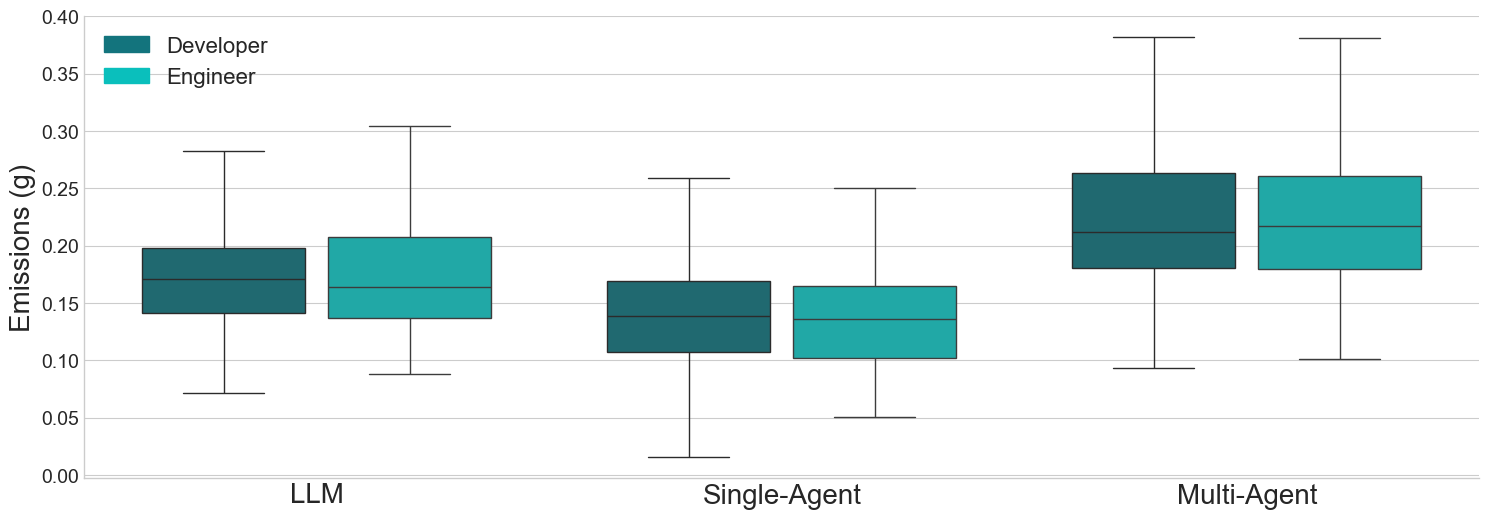

In [60]:
dev_data = pd.DataFrame({
    '00': qna_dev_00['emission_kg'] * 1000,
    '01': qna_dev_01['emission_kg'] * 1000,
    '02': qna_dev_02['emission_kg'] * 1000,
})

eng_data = pd.DataFrame({
    '00': qna_eng_00['emission_kg'] * 1000,
    '01': qna_eng_01['emission_kg'] * 1000,
    '02': qna_eng_02['emission_kg'] * 1000,
})

dev_melted = dev_data.melt(var_name='cenario', value_name='emissions')
eng_melted = eng_data.melt(var_name='cenario', value_name='emissions')

dev_melted['arquitetura'] = 'Developer'
eng_melted['arquitetura'] = 'Engineer'

final_df = pd.concat([dev_melted, eng_melted], ignore_index=True)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(18, 6))

df_dev = final_df[final_df['arquitetura'] == 'Developer']
df_eng = final_df[final_df['arquitetura'] == 'Engineer']

cenarios = ['00', '01', '02']
x_pos = np.arange(len(cenarios))
width = 0.35
dodge = 0.2

palette = {"Developer": "#13747d", "Engineer": "#0abfbc"}

sns.boxplot(
    data=df_dev, x='cenario', y='emissions',
    ax=ax, showfliers=False, width=width,
    positions=x_pos - dodge,
    color=palette["Developer"]
)

sns.boxplot(
    data=df_eng, x='cenario', y='emissions',
    ax=ax, showfliers=False, width=width,
    positions=x_pos + dodge,
    color=palette["Engineer"]
)

ax.set_xticks(x_pos)
ax.set_xticklabels(['LLM', 'Single-Agent', 'Multi-Agent'], fontsize=20)
plt.yticks(fontsize=14)

plt.ylabel("Emissions (g)", fontsize=20)
plt.xlabel("", fontsize=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

dev_patch = mpatches.Patch(color=palette["Developer"], label='Developer')
eng_patch = mpatches.Patch(color=palette["Engineer"], label='Engineer')
ax.legend(handles=[dev_patch, eng_patch], frameon=False, fontsize=16)

plt.show()

In [61]:
qna_dev_00_judge = pd.read_csv("./data/00_QnA_dev_judge.csv")
qna_eng_00_judge = pd.read_csv("./data/00_QnA_eng_judge.csv")

qna_dev_01_judge = pd.read_csv("./data/01_QnA_dev_judge.csv")
qna_eng_01_judge = pd.read_csv("./data/01_QnA_eng_judge.csv")

qna_dev_02_judge = pd.read_csv("./data/02_QnA_dev_judge.csv")
qna_eng_02_judge = pd.read_csv("./data/02_QnA_eng_judge.csv")

In [62]:
qna_dev_00_judge["Correct"].value_counts(), qna_dev_01_judge["Correct"].value_counts(), qna_dev_02_judge["Correct"].value_counts()

(Correct
 False    119
 True      31
 Name: count, dtype: int64,
 Correct
 False    79
 True     71
 Name: count, dtype: int64,
 Correct
 True     120
 False     30
 Name: count, dtype: int64)

In [63]:
qna_dev_00_judge["Relevant"].value_counts(), qna_dev_01_judge["Relevant"].value_counts(), qna_dev_02_judge["Relevant"].value_counts()

(Relevant
 True     147
 False      3
 Name: count, dtype: int64,
 Relevant
 True     148
 False      2
 Name: count, dtype: int64,
 Relevant
 True     149
 False      1
 Name: count, dtype: int64)

In [64]:
qna_dev_01_judge["Faithful"].value_counts(), qna_dev_02_judge["Faithful"].value_counts()

(Faithful
 False    79
 True     71
 Name: count, dtype: int64,
 Faithful
 True     120
 False     30
 Name: count, dtype: int64)

In [65]:
qna_eng_00_judge["Correct"].value_counts(), qna_eng_01_judge["Correct"].value_counts(), qna_eng_02_judge["Correct"].value_counts()

(Correct
 False    88
 True     62
 Name: count, dtype: int64,
 Correct
 True     97
 False    53
 Name: count, dtype: int64,
 Correct
 True     121
 False     29
 Name: count, dtype: int64)

In [66]:
qna_eng_00_judge["Relevant"].value_counts(), qna_eng_01_judge["Relevant"].value_counts(), qna_eng_02_judge["Relevant"].value_counts()

(Relevant
 True    150
 Name: count, dtype: int64,
 Relevant
 True    150
 Name: count, dtype: int64,
 Relevant
 True     143
 False      7
 Name: count, dtype: int64)

In [67]:
qna_eng_01_judge["Faithful"].value_counts(), qna_eng_02_judge["Faithful"].value_counts()

(Faithful
 True     97
 False    53
 Name: count, dtype: int64,
 Faithful
 True     121
 False     29
 Name: count, dtype: int64)

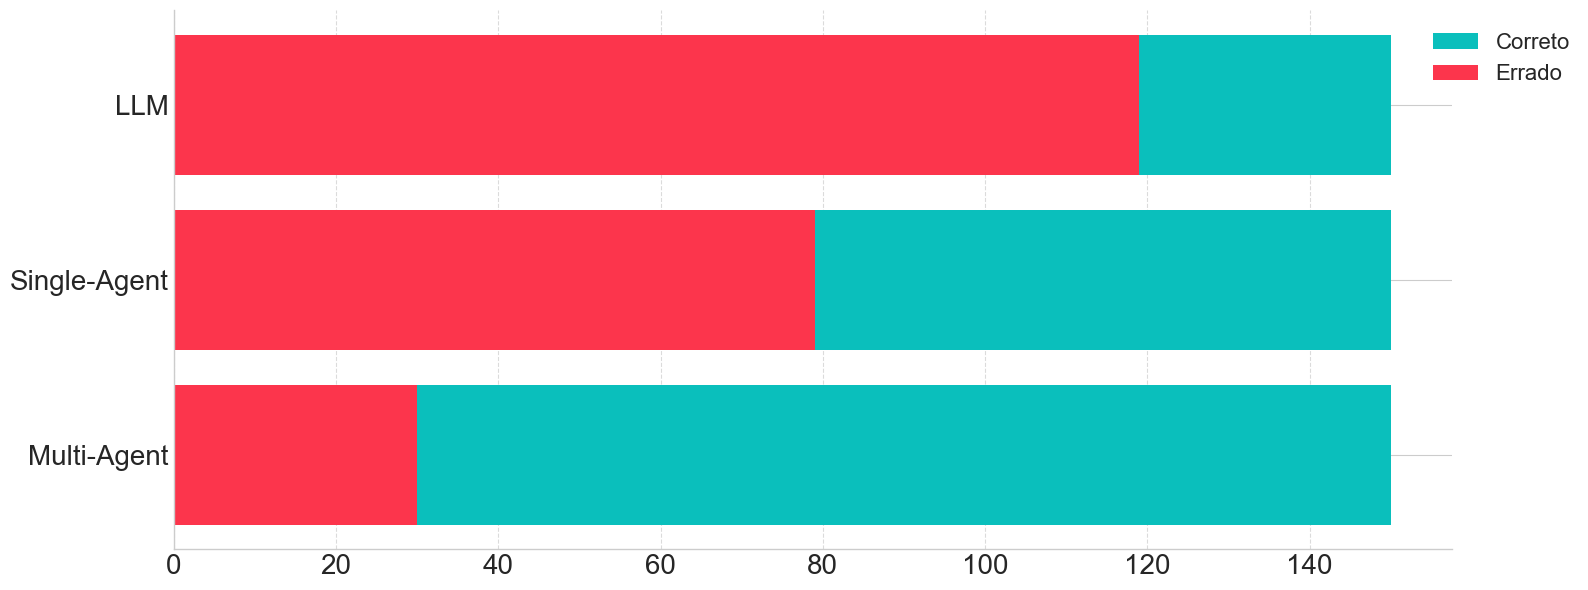

In [68]:
qna_dev_00_judge_correct_counts = pd.Series({'False': 119, 'True': 31}, name='Correct')
qna_dev_01_judge_correct_counts = pd.Series({'False': 79, 'True': 71}, name='Correct')
qna_dev_02_judge_correct_counts = pd.Series({'True': 120, 'False': 30}, name='Correct')

df_results = pd.DataFrame()

temp_df_00 = qna_dev_00_judge_correct_counts.rename('count').reset_index()
temp_df_00.columns = ['correctness', 'count']
temp_df_00['scenario'] = 'LLM'
df_results = pd.concat([df_results, temp_df_00])

temp_df_01 = qna_dev_01_judge_correct_counts.rename('count').reset_index()
temp_df_01.columns = ['correctness', 'count']
temp_df_01['scenario'] = 'Single-Agent'
df_results = pd.concat([df_results, temp_df_01])

temp_df_02 = qna_dev_02_judge_correct_counts.rename('count').reset_index()
temp_df_02.columns = ['correctness', 'count']
temp_df_02['scenario'] = 'Multi-Agent'
df_results = pd.concat([df_results, temp_df_02])

df_results['correctness'] = pd.Categorical(df_results['correctness'], categories=['True', 'False'], ordered=True)

colors = {'True': '#0abfbc', 'False': '#fc354c'}

plt.figure(figsize=(16, 6))

ax = sns.histplot(
    data=df_results,
    y='scenario',     
    weights='count',      
    hue='correctness',     
    multiple='stack',      
    palette=colors,        
    legend=True,
    shrink=0.8,
    linewidth=0,
    alpha=1
)

plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=0, fontsize=20)
plt.yticks(fontsize=20)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

legend = ax.get_legend()

new_labels = ['Correto', 'Errado']
for text, label in zip(legend.texts, new_labels):
    text.set_text(label)

legend.set_title('')

sns.move_legend(ax, "center left", bbox_to_anchor=(0.97, 0.91), fontsize=16, frameon=False)

plt.tight_layout()

plt.savefig(
    "./results/correctness_dev.pdf",
    dpi=300, 
    bbox_inches='tight',   
    pad_inches=0.1    
)

plt.show()

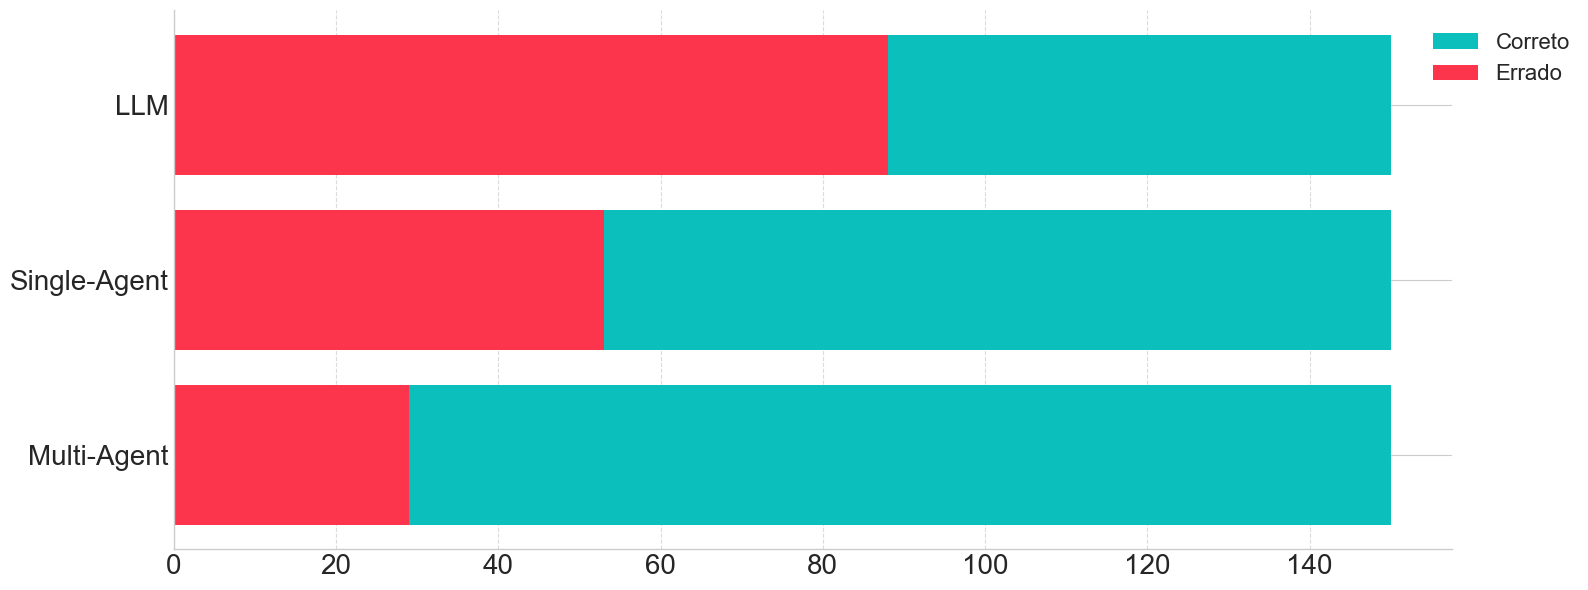

In [69]:
qna_eng_00_judge_correct_counts = pd.Series({'False': 88, 'True': 62}, name='Correct')
qna_eng_01_judge_correct_counts = pd.Series({'False': 53, 'True': 97}, name='Correct')
qna_eng_02_judge_correct_counts = pd.Series({'True': 121, 'False': 29}, name='Correct')

df_results = pd.DataFrame()

temp_df_00 = qna_eng_00_judge_correct_counts.rename('count').reset_index()
temp_df_00.columns = ['correctness', 'count']
temp_df_00['scenario'] = 'LLM'
df_results = pd.concat([df_results, temp_df_00])

temp_df_01 = qna_eng_01_judge_correct_counts.rename('count').reset_index()
temp_df_01.columns = ['correctness', 'count']
temp_df_01['scenario'] = 'Single-Agent'
df_results = pd.concat([df_results, temp_df_01])

temp_df_02 = qna_eng_02_judge_correct_counts.rename('count').reset_index()
temp_df_02.columns = ['correctness', 'count']
temp_df_02['scenario'] = 'Multi-Agent'
df_results = pd.concat([df_results, temp_df_02])

df_results['correctness'] = pd.Categorical(df_results['correctness'], categories=['True', 'False'], ordered=True)

colors = {'True': '#0abfbc', 'False': '#fc354c'}

plt.figure(figsize=(16, 6))

ax = sns.histplot(
    data=df_results,
    y='scenario',     
    weights='count',      
    hue='correctness',     
    multiple='stack',      
    palette=colors,        
    legend=True,
    shrink=0.8,
    linewidth=0,
    alpha=1
)

plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=0, fontsize=20)
plt.yticks(fontsize=20)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

legend = ax.get_legend()

new_labels = ['Correto', 'Errado']
for text, label in zip(legend.texts, new_labels):
    text.set_text(label)

legend.set_title('')

sns.move_legend(ax, "center left", bbox_to_anchor=(0.97, 0.91), fontsize=16, frameon=False)

plt.tight_layout()

plt.savefig(
    "./results/correctness_eng.pdf",
    dpi=300,
    bbox_inches='tight',  
    pad_inches=0.1  
)

plt.show()

In [ ]:
dev_stats_flesch_reading_ease = pd.read_csv("./data/dev_stats_flesch_reading_ease.csv").drop(columns=["Unnamed: 0"])
dev_stats_flesch_reading_ease.columns = [f"developer_{i+1}.pdf" for i in range(len(dev_stats_flesch_reading_ease.columns))]
dev_stats_flesch_reading_ease["type"] = "Desenvolvedor"
dev_flesch_melted = dev_stats_flesch_reading_ease.melt(id_vars=['type'], var_name='doc', value_name='readability_score')

eng_stats_flesch_reading_ease = pd.read_csv("./data/eng_stats_flesch_reading_ease.csv").drop(columns=["Unnamed: 0"])
eng_stats_flesch_reading_ease.columns = [f"engineer_{i+1}.pdf" for i in range(len(eng_stats_flesch_reading_ease.columns))]
eng_stats_flesch_reading_ease["type"] = "Engenheiro"
eng_flesch_melted = eng_stats_flesch_reading_ease.melt(id_vars=['type'], var_name='doc', value_name='readability_score')

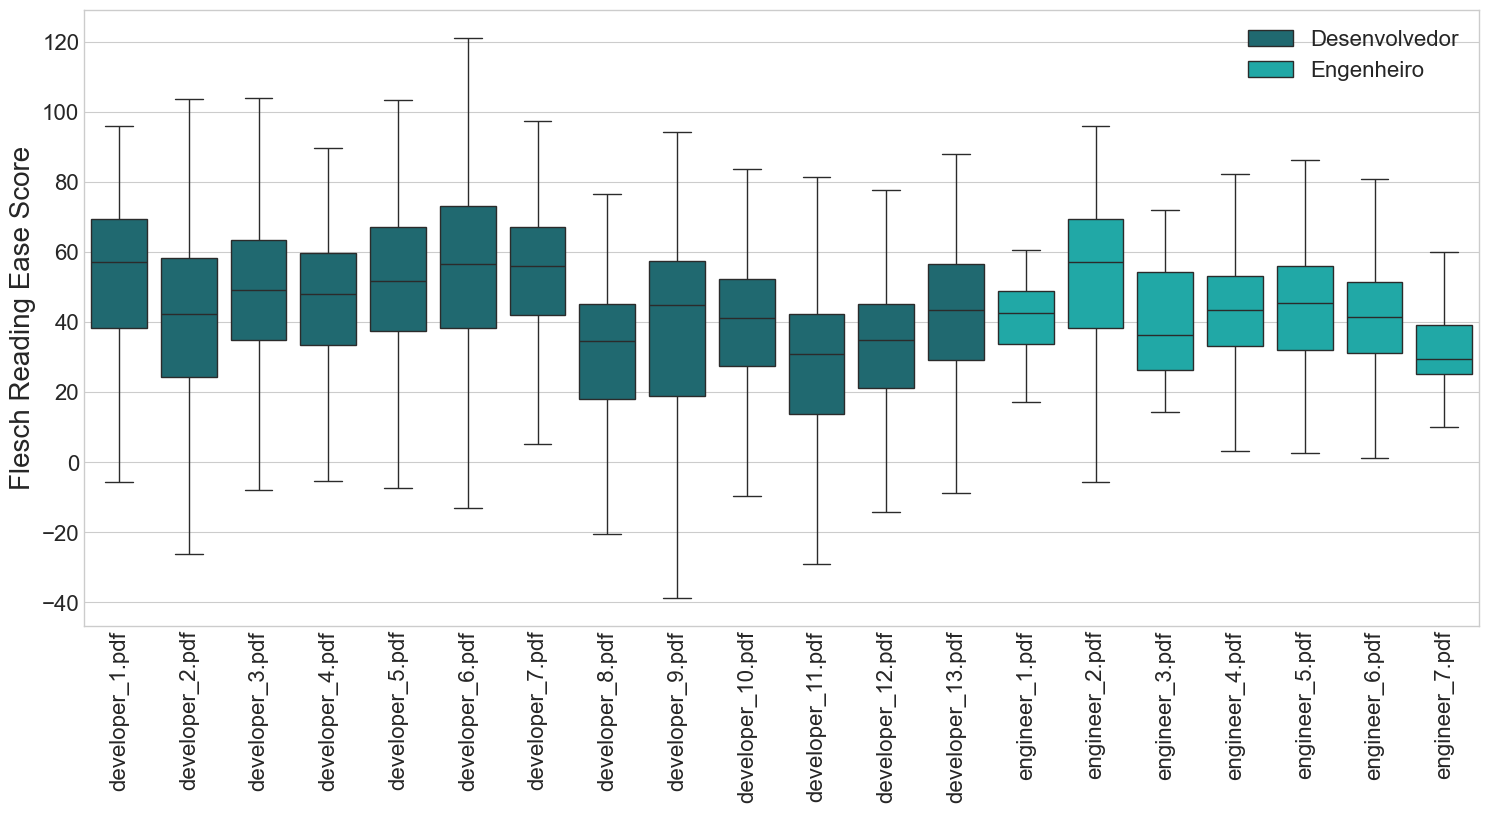

In [71]:
df_flesch_combined = pd.concat([dev_flesch_melted, eng_flesch_melted], ignore_index=True)

plt.figure(figsize=(18, 8))
sns.boxplot(
    x='doc', 
    y='readability_score', 
    data=df_flesch_combined, 
    hue='type', 
    showfliers=False,
    palette={'Desenvolvedor': '#13747d', 'Engenheiro': '#0abfbc'}
)
plt.xlabel('')
plt.ylabel('Flesch Reading Ease Score', fontsize=20)
plt.yticks(fontsize=16)
plt.xticks(rotation=90, fontsize=16)

plt.legend(title='', frameon=False, fontsize=16)

plt.savefig(
    "./results/flesch_reading_dataset.pdf",
    dpi=300,                 # Resolução (300 é o padrão mínimo para impressão)
    bbox_inches='tight',     # Remove as bordas brancas excessivas
    pad_inches=0.1           # Margem de segurança pequena
)

plt.show()

In [72]:
dev_stats_flesch_reading_ease.describe().T["50%"] <= 50

developer_1.pdf     False
developer_2.pdf      True
developer_3.pdf      True
developer_4.pdf      True
developer_5.pdf     False
developer_6.pdf     False
developer_7.pdf     False
developer_8.pdf      True
developer_9.pdf      True
developer_10.pdf     True
developer_11.pdf     True
developer_12.pdf     True
developer_13.pdf     True
Name: 50%, dtype: bool

In [73]:
eng_stats_flesch_reading_ease.describe().T["50%"] <= 50

engineer_1.pdf     True
engineer_2.pdf    False
engineer_3.pdf     True
engineer_4.pdf     True
engineer_5.pdf     True
engineer_6.pdf     True
engineer_7.pdf     True
Name: 50%, dtype: bool

In [74]:
selected_eng_01 = [122, 235, 277, 182, 133, 222, 114, 154, 264, 187, 253, 209, 259, 10, 46, 262, 290, 261, 219, 189, 192, 153, 245, 21, 260, 275, 145, 223, 59, 220, 267, 47, 120, 169, 136, 299, 272, 229, 237, 188, 274, 98, 180, 24, 283, 99, 135, 225, 158, 57, 190, 85, 213, 186, 72, 74, 268, 230, 43, 71, 195, 269, 100, 23, 138, 298, 6, 276, 144, 11, 157, 27, 210, 49]
selected_eng_02 = [277, 182, 222, 107, 226, 154, 264, 33, 209, 259, 10, 46, 262, 290, 261, 219, 189, 153, 63, 21, 202, 20, 128, 145, 131, 146, 22, 220, 267, 47, 120, 299, 272, 227, 229, 237, 90, 188, 203, 4, 98, 180, 204, 24, 211, 283, 99, 135, 225, 244, 115, 158, 130, 293, 155, 270, 190, 75, 85, 213, 186, 55, 72, 95, 196, 74, 268, 214, 143, 230, 289, 29, 43, 252, 280, 195, 9, 269, 167, 118, 138, 175, 298, 6, 144, 11, 27, 210, 111, 109, 247, 49]

selected_eng = set(selected_eng_01).intersection(set(selected_eng_02))

In [75]:
len(selected_eng_01), len(selected_eng_02)

(74, 92)

In [76]:
selected_eng = [val - 1 for val in selected_eng]

In [77]:
len(selected_eng)

53

In [78]:
qna_eng_00 = pd.read_csv("./data/00_QnA_eng.csv")
qna_eng_01 = pd.read_csv("./data/01_QnA_eng.csv")
qna_eng_02 = pd.read_csv("./data/02_QnA_eng.csv")

qna_eng_00["Correct"] = pd.read_csv("./data/00_QnA_eng_judge.csv")["Correct"]
qna_eng_01["Correct"] = pd.read_csv("./data/01_QnA_eng_judge.csv")["Correct"]
qna_eng_02["Correct"] = pd.read_csv("./data/02_QnA_eng_judge.csv")["Correct"]

qna_eng_00_selected = qna_eng_00[qna_eng_00["id"].isin(selected_eng)]
qna_eng_01_selected = qna_eng_01[qna_eng_01["id"].isin(selected_eng)]
qna_eng_02_selected = qna_eng_02[qna_eng_02["id"].isin(selected_eng)]

In [79]:
qna_eng_selected = qna_eng_00_selected.merge(qna_eng_01_selected, on='id').merge(qna_eng_02_selected, on='id')
qna_eng_selected = qna_eng_selected.rename(columns={
    "response_x": "00",
    "response_y": "01",
    "response": "02"
})

In [80]:
qna_eng_selected = qna_eng_selected[["id", "question", "00", "01", "02"]]

qna_eng_selected['00'] = qna_eng_selected['00'].fillna("Not answered")
qna_eng_selected['01'] = qna_eng_selected['01'].fillna("Not answered")
qna_eng_selected['02'] = qna_eng_selected['02'].fillna("Not answered")

In [81]:
from docx import Document
from docx.shared import Pt, Inches


doc = Document()

for idx, row in qna_eng_selected.iterrows():
    p_pergunta = doc.add_paragraph()
    run_pergunta = p_pergunta.add_run(f"{row['id']}: {row['question']}")
    run_pergunta.bold = True
    

    p_resp_00 = doc.add_paragraph()
    run_resp_00 = p_resp_00.add_run("[Correct | Wrong] Person 1:")
    run_resp_00.font.size = Pt(12)
    run_resp_00.bold = True

    p_texto_00 = doc.add_paragraph()
    run_texto_00 = p_texto_00.add_run(row['02'])
    run_texto_00.italic = True
    p_texto_00.paragraph_format.left_indent = Inches(0.5)


    p_resp_01 = doc.add_paragraph()
    run_resp_01 = p_resp_01.add_run("[Correct | Wrong] Person 2:")
    run_resp_01.font.size = Pt(12) 
    run_resp_01.bold = True       

    p_texto_01 = doc.add_paragraph()
    run_texto_01 = p_texto_01.add_run(row['00'])
    run_texto_01.italic = True                        
    p_texto_01.paragraph_format.left_indent = Inches(0.5) 


    p_resp_02 = doc.add_paragraph()
    run_resp_02 = p_resp_02.add_run("[Correct | Wrong] Person 3:")
    run_resp_02.font.size = Pt(12) 
    run_resp_02.bold = True       

    p_texto_02 = doc.add_paragraph()
    run_texto_02 = p_texto_02.add_run(row['01'])
    run_texto_02.italic = True                        
    p_texto_02.paragraph_format.left_indent = Inches(0.5) 
    

    doc.add_paragraph() 

nome_arquivo = 'questions.docx'
doc.save(nome_arquivo)

ModuleNotFoundError: No module named 'exceptions'

In [ ]:
qna_eng_00_judge["id"] = qna_eng_00["id"]
qna_eng_01_judge["id"] = qna_eng_01["id"]
qna_eng_02_judge["id"] = qna_eng_02["id"]

qna_eng_00_judge_correct = qna_eng_00_judge[qna_eng_00_judge["id"].isin(qna_eng_selected["id"])]["Correct"]
qna_eng_01_judge_correct = qna_eng_01_judge[qna_eng_01_judge["id"].isin(qna_eng_selected["id"])]["Correct"]
qna_eng_02_judge_correct = qna_eng_02_judge[qna_eng_02_judge["id"].isin(qna_eng_selected["id"])]["Correct"]

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
pd.DataFrame({
    "id": qna_eng_selected["id"].to_list(),
    "00": qna_eng_00_judge_correct.to_list(),
    "01": qna_eng_01_judge_correct.to_list(),
    "02": qna_eng_02_judge_correct.to_list()
}).to_csv("llm-as-a-judge.csv", index=False)

In [ ]:
tmp = pd.read_excel("./data/index.xlsx")
tmp = tmp.fillna(0.0)

In [ ]:
confusion_matrix(tmp["0_human"], tmp["0_judge"]), accuracy_score(tmp["0_human"], tmp["0_judge"])

(array([[12, 18],
        [12, 11]]),
 0.4339622641509434)

In [ ]:
confusion_matrix(tmp["1_human"].fillna(0), tmp["1_judge"]), accuracy_score(tmp["1_human"].fillna(0), tmp["1_judge"])

(array([[ 6, 19],
        [ 5, 23]]),
 0.5471698113207547)

In [ ]:
confusion_matrix(tmp["2_human"].fillna(0), tmp["2_judge"]), accuracy_score(tmp["2_human"].fillna(0), tmp["2_judge"])

(array([[ 5, 13],
        [ 2, 33]]),
 0.7169811320754716)

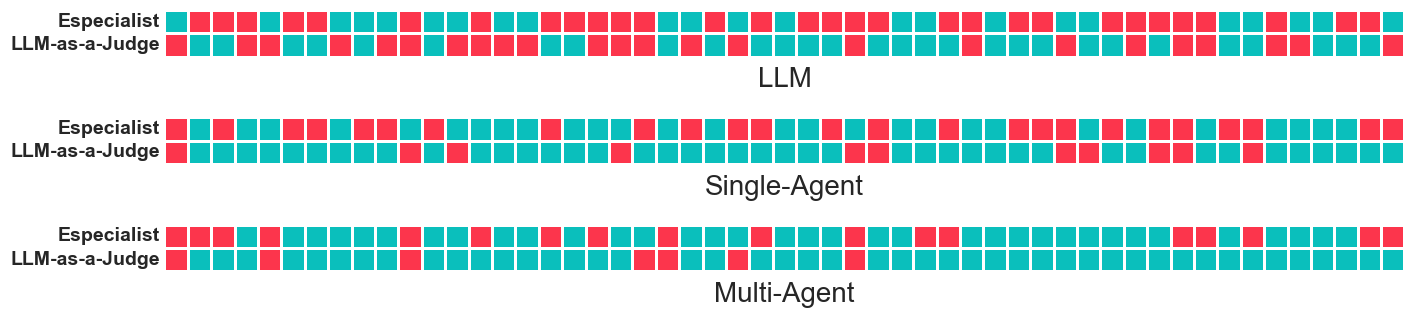

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

datasets = [
    [
        tmp["0_human"],
        tmp["0_judge"]
    ],
    [
        tmp["1_human"],
        tmp["1_judge"]
    ],
    [
        tmp["2_human"],
        tmp["2_judge"]
    ]
]

scenarios = ["LLM", "Single-Agent", "Multi-Agent"]

cmap = ListedColormap(['#fc354c', '#0abfbc'])

fig, axes = plt.subplots(3, 1, figsize=(16, 4), gridspec_kw={'hspace': 0.15})

for i, ax in enumerate(axes):
    y_true, y_pred = datasets[i]
    
    comparacao = np.vstack([y_true, y_pred])
    
    sns.heatmap(
        comparacao, 
        ax=ax, 
        cmap=cmap, 
        linewidths=0.9, 
        linecolor='white', 
        square=True,
        cbar=False,
        annot=False
    )
    
    ax.set_yticklabels(['Especialist', 'LLM-as-a-Judge'], rotation=0, fontsize=14, fontweight='bold')
    ax.set_xticklabels([])
    ax.set_xlabel(scenarios[i], fontsize=20)

plt.savefig(
    "./results/llm_as_a_judge_vs_especialist.pdf",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.1
)

plt.show()

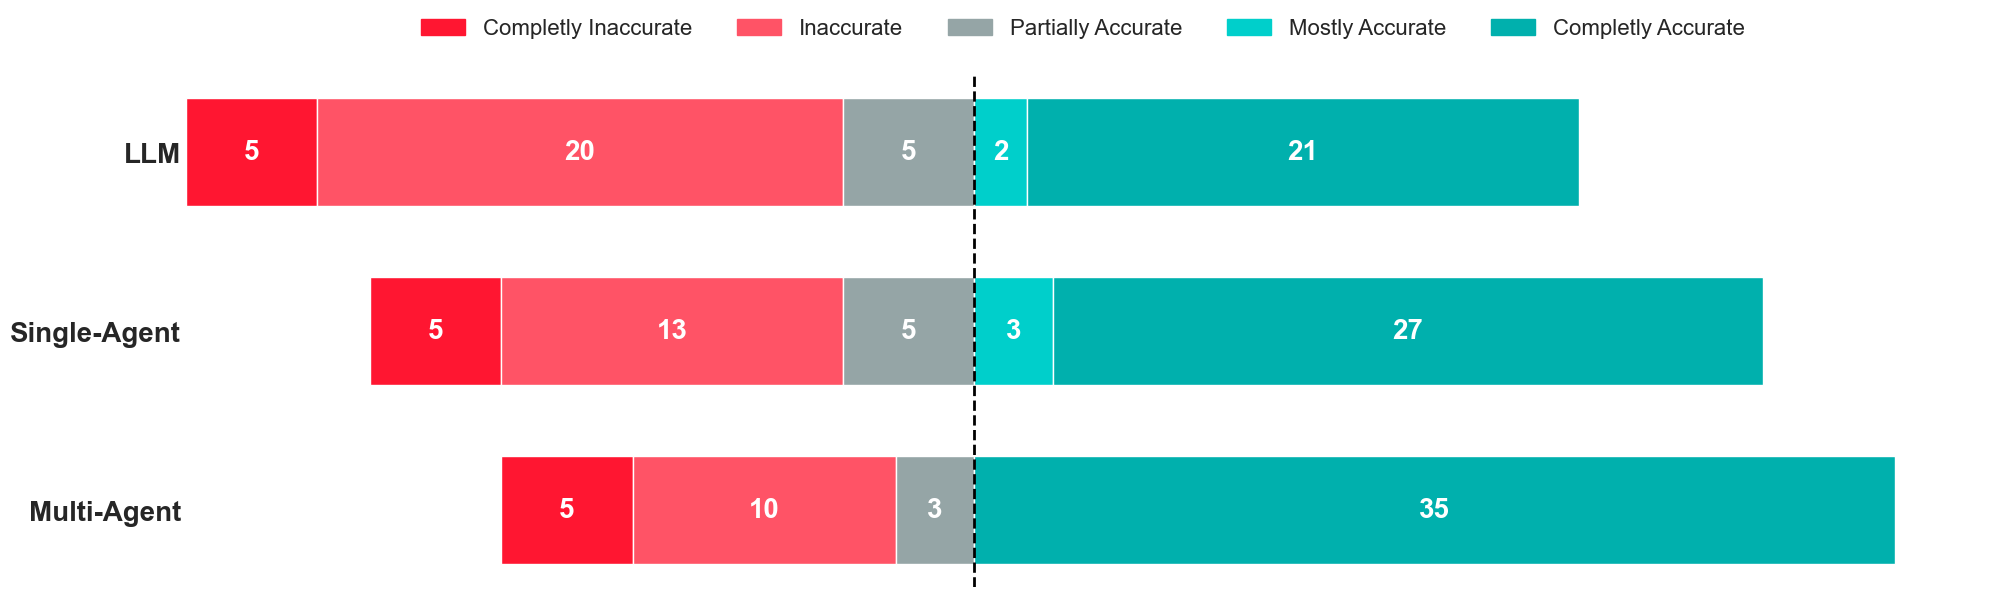

In [ ]:

data = {
    'Completly Inaccurate': [5, 5,  5],  # Cor 1
    'Inaccurate': [10, 13, 20],  # Cor 2
    'Partially Accurate': [3, 5, 5],  # Cor 3
    'Mostly Accurate': [0, 3, 2],  # Cor 4
    'Completly Accurate': [35, 27, 21]   # Cor 5
}

linhas = ['Multi-Agent', 'Single-Agent', 'LLM']

df = pd.DataFrame(data, index=linhas)

colors = ['#FF1631', '#FF5366', '#95a5a6', '#00CFCB', '#00B0AD']

fig, ax = plt.subplots(figsize=(20, 6))

split_index = 2 

for i, (idx, row) in enumerate(df.iterrows()):
    vals = row.values
    cumsum = vals.cumsum()

    offset = cumsum[split_index]

    starts = cumsum - vals - offset
    
    for j, val in enumerate(vals):
        if val == 0:
            continue
            
        ax.barh(i, val, left=starts[j], height=0.6, color=colors[j], edgecolor='white')

        if val > 0: 
            x_center = starts[j] + val/2
            ax.text(x_center, i, f"{int(val)}", ha='center', va='center', 
                    color='white', fontsize=20, fontweight='bold')

ax.axvline(0, color='black', linewidth=2, linestyle='--')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df.index, fontsize=20, fontweight='bold')

ax.get_xaxis().set_visible(False)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors]
ax.legend(handles, df.columns, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=5, frameon=False, fontsize=16)

ax.grid(False)
plt.tight_layout()

plt.show()